In [1]:
%matplotlib widget

In [2]:
import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import math
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import sys
sys.path.insert(1, '../src')

In [3]:
data = np.load('DippingTopo.npy')

In [4]:
thetas = np.arange(-10,10)
thetasr = np.deg2rad(thetas)
sigmas = np.logspace(0,3)/1000

In [5]:
data = data.reshape(len(thetas), len(sigmas), 18)

In [6]:
idx = np.argmin(np.abs(thetas))

In [7]:
dat_0 = np.zeros_like(data)

for i, t in enumerate(thetas):
    for j, s in enumerate(sigmas):
        dat_0[i, j, :] = data[idx, j, :]

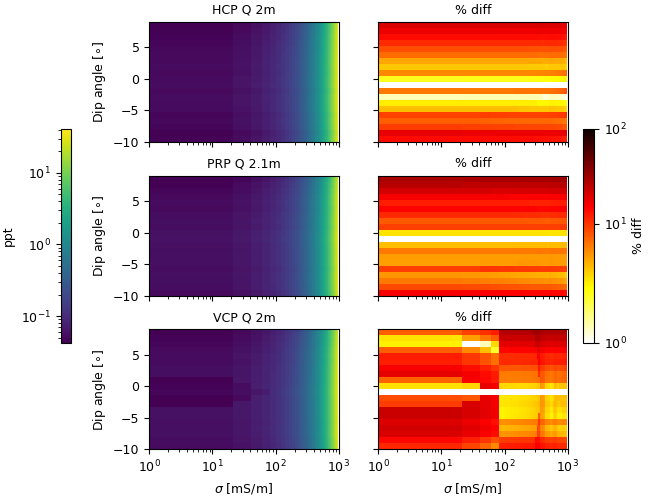

In [10]:
fig, ax = plt.subplots(3,2, figsize=(6.5,5), sharex=True, sharey=True, layout='constrained')

asp = .1
ext = [sigmas[0]*1000, sigmas[-1]*1000, thetas[0], thetas[-1]]
cmap='hot_r'

fs=9
vmin =  1
vmax = 100

keys = ['HCP Q 2m', 'PRP Q 2.1m', 'VCP Q 2m',]
for i, k in enumerate(keys):
    j = i*3
   # print('i:', i)
   # print('j:', j)
    c1 = ax[i,0].imshow(data[:,:, j]*1000, extent= ext, aspect =asp, norm='log', )
    c2 = ax[i,1].imshow(np.abs((data[:, :, j] - dat_0[:, :, j])/dat_0[:, :, j])*100, cmap= cmap, extent=ext, aspect=asp, vmin = vmin, vmax=vmax, norm='symlog')
    ax[i,0].set_xscale('log')
    ax[i,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
    ax[i,0].set_title(k, fontsize=fs)
    ax[i,1].set_title('% diff', fontsize=fs)
    ax[i,0].tick_params(labelsize=fs)
    ax[i,1].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location='left', shrink=0.5, pad=0.02)
cb1.set_label('ppt', fontsize=fs)
cb1.ax.tick_params( labelsize=fs)
cb2 = fig.colorbar(c2, ax=ax, location ='right', shrink=0.5, pad=0.01)
cb2.set_label('% diff', fontsize=fs)
cb2.ax.tick_params( labelsize=fs)

ax[-1,0].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)
ax[-1,1].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)

plt.show()
plt.savefig('DippingTopo_Q_2m.eps', format='eps')

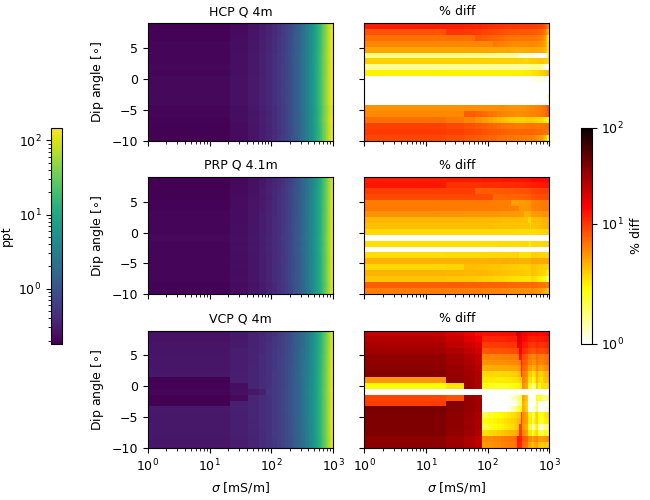

In [12]:
fig, ax = plt.subplots(3,2, figsize=(6.5,5), sharex=True, sharey=True, layout='constrained')

asp = .1
ext = [sigmas[0]*1000, sigmas[-1]*1000, thetas[0], thetas[-1]]
cmap='hot_r'

fs=9
vmin = 1
vmax = 100

keys = ['HCP Q 4m', 'PRP Q 4.1m', 'VCP Q 4m',]
for i, k in enumerate(keys):
    j = (i*3)+1
  #  print('i:', i)
  #  print('j:', j)
  #  print('j*3: ', j*3)
    c1 = ax[i,0].imshow(data[:,:, j]*1000, extent= ext, aspect =asp, norm='log', )
    c2 = ax[i,1].imshow(np.abs((data[:, :, j] - dat_0[:,:,j])/dat_0[:,:,j])*100, cmap= cmap, extent=ext, aspect=asp, vmin=vmin, vmax=vmax, norm='symlog')
    ax[i,0].set_xscale('log')
    ax[i,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
    ax[i,0].set_title(k, fontsize=fs)
    ax[i,1].set_title('% diff', fontsize=fs)
    ax[i,0].tick_params(labelsize=fs)
    ax[i,1].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location='left', shrink=0.5)
cb1.set_label('ppt', fontsize=fs)
cb1.ax.tick_params( labelsize=fs)
cb2 = fig.colorbar(c2, ax=ax, location ='right', shrink=0.5)
cb2.set_label('% diff', fontsize=fs)
cb2.ax.tick_params( labelsize=fs)

ax[-1,0].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)
ax[-1,1].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)

plt.show()
plt.savefig('DippingTopo_Q_4m.eps', format='eps')

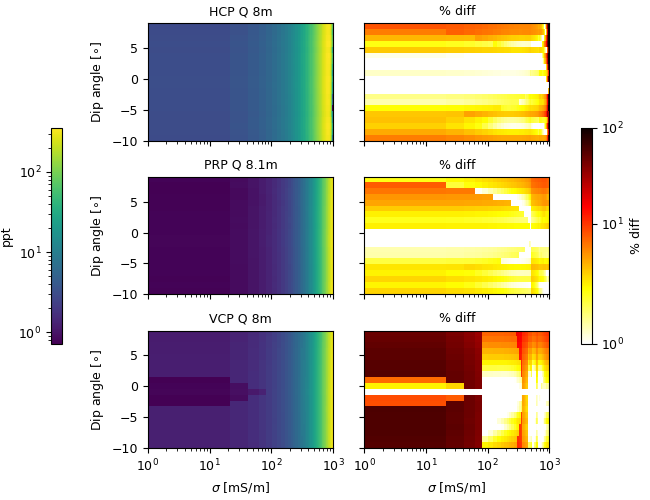

In [13]:
fig, ax = plt.subplots(3,2, figsize=(6.5,5), sharex=True, sharey=True, layout='constrained')

asp = .1
ext = [sigmas[0]*1000, sigmas[-1]*1000, thetas[0], thetas[-1]]
cmap='hot_r'

fs=9
vmin = 1
vmax = 100

keys = ['HCP Q 8m', 'PRP Q 8.1m', 'VCP Q 8m',]
for i, k in enumerate(keys):
    j = (i*3)+2
 #   print('i:', i)
 #   print('j:', j)
  #  print('j*3: ', j*3)
    c1 = ax[i,0].imshow(data[:,:, j]*1000, extent= ext, aspect =asp, norm='log', )
    c2 = ax[i,1].imshow(np.abs((data[:, :, j] - dat_0[:,:,j])/dat_0[:,:,j])*100, cmap= cmap, extent=ext, aspect=asp, vmin=vmin, vmax=vmax, norm = 'symlog')
    ax[i,0].set_xscale('log')
    ax[i,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
    ax[i,0].set_title(k, fontsize=fs)
    ax[i,1].set_title('% diff', fontsize=fs)
    ax[i,0].tick_params(labelsize=fs)
    ax[i,1].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location='left', shrink=0.5)
cb1.set_label('ppt', fontsize=fs)
cb1.ax.tick_params( labelsize=fs)
cb2 = fig.colorbar(c2, ax=ax, location ='right', shrink=0.5)
cb2.set_label('% diff', fontsize=fs)
cb2.ax.tick_params( labelsize=fs)

ax[-1,0].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)
ax[-1,1].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)

plt.show()
plt.savefig('DippingTopo_Q_8m.eps', format='eps')

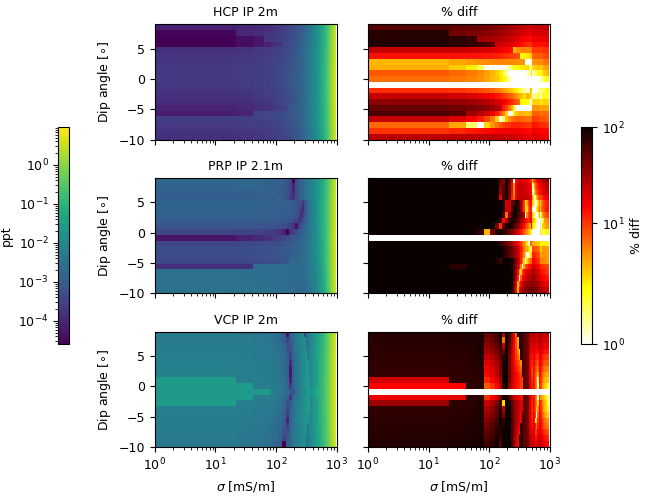

In [14]:
fig, ax = plt.subplots(3,2, figsize=(6.5,5), sharex=True, sharey=True, layout='constrained')

asp = .1
ext = [sigmas[0]*1000, sigmas[-1]*1000, thetas[0], thetas[-1]]
cmap='hot_r'


fs=9
vmin = 1
vmax = 100

keys = ['HCP IP 2m', 'PRP IP 2.1m', 'VCP IP 2m',]
for i, k in enumerate(keys):
    j = (i*3)+9
  #  print('i:', i)
  #  print('j:', j)
  #  print('j*3: ', j*3)
    c1 = ax[i,0].imshow(data[:,:, j]*1000, extent= ext, aspect =asp, norm='log', )
    c2 = ax[i,1].imshow(np.abs((data[:, :, j] - dat_0[:,:,j])/dat_0[:,:,j])*100, cmap= cmap, extent=ext, aspect=asp, vmin=vmin, vmax=vmax, norm='symlog')
    ax[i,0].set_xscale('log')
    ax[i,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
    ax[i,0].set_title(k, fontsize=fs)
    ax[i,1].set_title('% diff', fontsize=fs)
    ax[i,0].tick_params(labelsize=fs)
    ax[i,1].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location='left', shrink=0.5)
cb1.set_label('ppt', fontsize=fs)
cb1.ax.tick_params( labelsize=fs)
cb2 = fig.colorbar(c2, ax=ax, location ='right', shrink=0.5)
cb2.set_label('% diff', fontsize=fs)
cb2.ax.tick_params( labelsize=fs)

ax[-1,0].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)
ax[-1,1].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)

plt.show()
plt.savefig('DippingTopo_IP_2m.eps', format='eps')

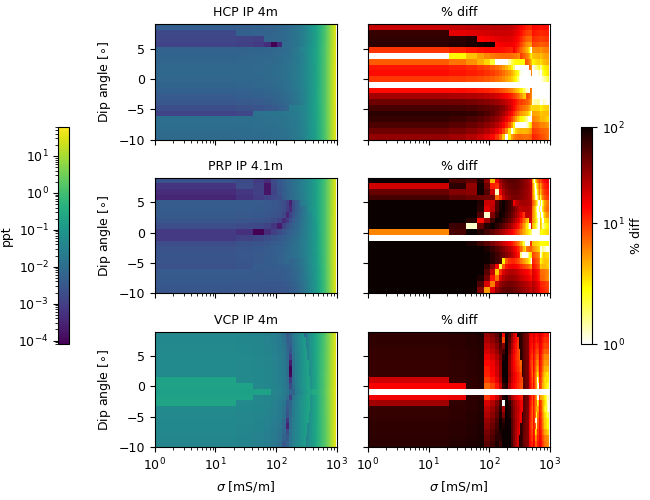

In [15]:
fig, ax = plt.subplots(3,2, figsize=(6.5,5), sharex=True, sharey=True, layout='constrained')

asp = .1
ext = [sigmas[0]*1000, sigmas[-1]*1000, thetas[0], thetas[-1]]
cmap='hot_r'

fs=9
vmin = 1
vmax = 100

keys = ['HCP IP 4m', 'PRP IP 4.1m', 'VCP IP 4m',]
for i, k in enumerate(keys):
    j = (i*3)+10
 #   print('i:', i)
 #   print('j:', j)
  #  print('j*3: ', j*3)
    c1 = ax[i,0].imshow(data[:,:, j]*1000, extent= ext, aspect =asp, norm='log', )
    c2 = ax[i,1].imshow(np.abs((data[:, :, j] - dat_0[:,:,j])/dat_0[:,:,j])*100, cmap= cmap, extent=ext, aspect=asp, vmin=vmin, vmax=vmax, norm='symlog')
    ax[i,0].set_xscale('log')
    ax[i,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
    ax[i,0].set_title(k, fontsize=fs)
    ax[i,1].set_title('% diff', fontsize=fs)
    ax[i,0].tick_params(labelsize=fs)
    ax[i,1].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location='left', shrink=0.5)
cb1.set_label('ppt', fontsize=fs)
cb1.ax.tick_params( labelsize=fs)
cb2 = fig.colorbar(c2, ax=ax, location ='right', shrink=0.5)
cb2.set_label('% diff', fontsize=fs)
cb2.ax.tick_params( labelsize=fs)

ax[-1,0].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)
ax[-1,1].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)

plt.show()
plt.savefig('DippingTopo_IP_4m.eps', format='eps')

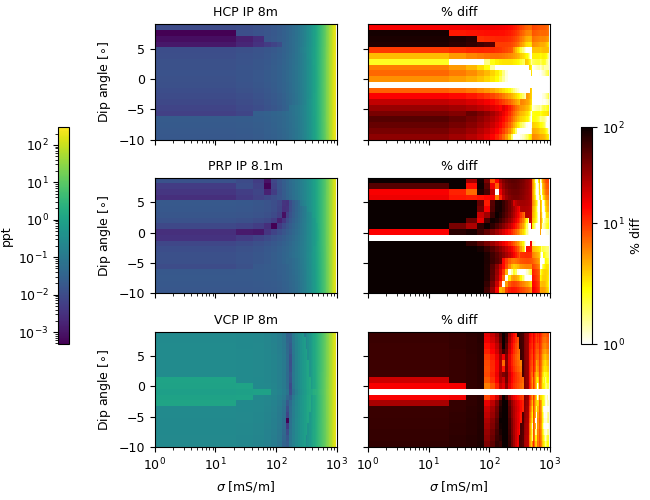

In [16]:
fig, ax = plt.subplots(3,2, figsize=(6.5,5), sharex=True, sharey=True, layout='constrained')

asp = .1
ext = [sigmas[0]*1000, sigmas[-1]*1000, thetas[0], thetas[-1]]
cmap='hot_r'

fs=9
vmin = 1
vmax = 100

keys = ['HCP IP 8m', 'PRP IP 8.1m', 'VCP IP 8m',]
for i, k in enumerate(keys):
    j = (i*3)+11
  #  print('i:', i)
  #  print('j:', j)
  #  print('j*3: ', j*3)
    c1 = ax[i,0].imshow(data[:,:, j]*1000, extent= ext, aspect =asp, norm='log', )
    c2 = ax[i,1].imshow(np.abs((data[:, :, j] - dat_0[:,:,j])/dat_0[:,:,j])*100, cmap= cmap, extent=ext, aspect=asp, vmin=vmin, vmax=vmax, norm='symlog')
    ax[i,0].set_xscale('log')
    ax[i,0].set_ylabel('Dip angle [$\circ$]', fontsize=fs)
    ax[i,0].set_title(k, fontsize=fs)
    ax[i,1].set_title('% diff', fontsize=fs)
    ax[i,0].tick_params(labelsize=fs)
    ax[i,1].tick_params(labelsize=fs)

cb1 = fig.colorbar(c1, ax=ax, location='left', shrink=0.5)
cb1.set_label('ppt', fontsize=fs)
cb1.ax.tick_params( labelsize=fs)
cb2 = fig.colorbar(c2, ax=ax, location ='right', shrink=0.5)
cb2.set_label('% diff', fontsize=fs)
cb2.ax.tick_params( labelsize=fs)

ax[-1,0].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)
ax[-1,1].set_xlabel('$\sigma$ [mS/m]', fontsize=fs)

plt.show()
plt.savefig('DippingTopo_IP_8m.eps', format='eps')